In [ ]:
import numpy as np
import pandas as pd
import cv2
import mediapipe as mp
import sklearn
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/KOA-PD-NM"

print(os.listdir(DATASET_PATH))

['KOA-PD-NM']


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM"

print(os.listdir(DATASET_PATH))


['KOA', 'NM', 'PD']


In [ ]:
from pathlib import Path

dataset = Path(DATASET_PATH)

folders = {
    "KOA_EL": dataset / "KOA" / "KOA_EL",
    "KOA_MD": dataset / "KOA" / "KOA_MD",
    "KOA_SV": dataset / "KOA" / "KOA_SV",
    "NM": dataset / "NM"
}

for name, folder in folders.items():
    videos = sorted(folder.glob("*.MOV"))
    print(f"{name:8} → {len(videos):3} videos")

print("-" * 35)

total = sum(len(list(folder.glob("*.MOV"))) for folder in folders.values())

print(f"TOTAL    → {total:3} videos")

KOA_EL   →  30 videos
KOA_MD   →  40 videos
KOA_SV   →  30 videos
NM       →  60 videos
-----------------------------------
TOTAL    → 160 videos


In [ ]:
records = []

for severity, folder in [
    ("EL", folders["KOA_EL"]),
    ("MD", folders["KOA_MD"]),
    ("SV", folders["KOA_SV"])
]:

    for video in sorted(folder.glob("*.MOV")):
        name = video.stem

        # Example: 001_KOA_01_EL
        parts = name.split("_")

        subject_id = parts[0]
        disease = parts[1]
        sequence = parts[2]

        records.append({
            "subject_id": subject_id,
            "disease": disease,
            "severity": severity,
            "sequence": sequence,
            "filename": video.name,
            "path": str(video)
        })


# Add healthy/normal videos
for video in sorted(folders["NM"].glob("*.MOV")):
    name = video.stem

    # Example: 001_NM_01
    parts = name.split("_")

    subject_id = parts[0]
    disease = parts[1]
    sequence = parts[2]

    records.append({
        "subject_id": subject_id,
        "disease": "NM",
        "severity": "NORMAL",
        "sequence": sequence,
        "filename": video.name,
        "path": str(video)
    })


df = pd.DataFrame(records)

print("Number of videos:", len(df))
df.head(10)

Number of videos: 160


,subject_id,disease,severity,sequence,filename,path
0,001,KOA,EL,01,001_KOA_01_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...
1,001,KOA,EL,02,001_KOA_02_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...
2,002,KOA,EL,01,002_KOA_01_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...
3,002,KOA,EL,02,002_KOA_02_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...
4,003,KOA,EL,01,003_KOA_01_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...
5,003,KOA,EL,02,003_KOA_02_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...
6,004,KOA,EL,01,004_KOA_01_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...
7,004,KOA,EL,02,004_KOA_02_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...
8,005,KOA,EL,01,005_KOA_01_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...
9,005,KOA,EL,02,005_KOA_02_EL.MOV,/content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA...


In [ ]:
print("Videos per disease:")
print(df["disease"].value_counts())

print("\nVideos per severity:")
print(df["severity"].value_counts())

print("\nVideos per sequence:")
print(df["sequence"].value_counts())

Videos per disease:
disease
KOA    100
NM      60
Name: count, dtype: int64

Videos per severity:
severity
NORMAL    60
MD        40
EL        30
SV        30
Name: count, dtype: int64

Videos per sequence:
sequence
01    80
02    80
Name: count, dtype: int64


In [ ]:
duplicates = df[df.duplicated("filename", keep=False)]

if len(duplicates) == 0:
    print("No duplicate filenames ✅")
else:
    print("Duplicates found:")
    display(duplicates)

No duplicate filenames ✅


In [ ]:
df.to_csv("/content/drive/MyDrive/KOA-PD-NM/video_metadata.csv", index=False)

print("Saved video_metadata.csv ✅")

Saved video_metadata.csv ✅


Testing: /content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA/KOA_EL/001_KOA_01_EL.MOV


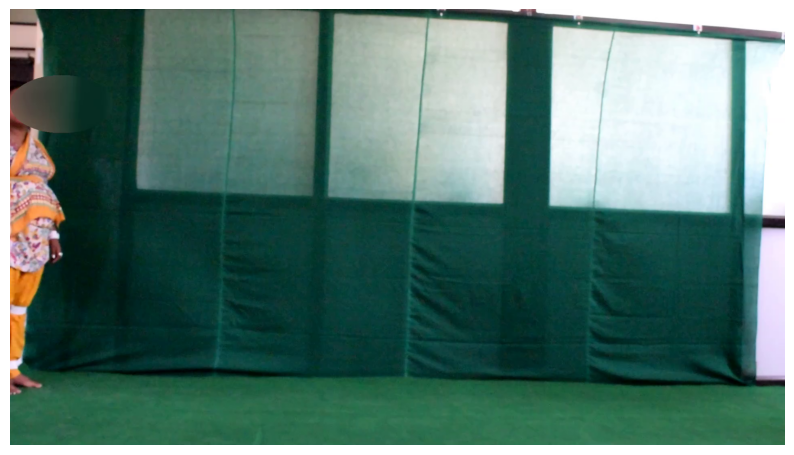

✅ First frame read successfully


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Get the video path from our metadata table
test_video = df.iloc[0]["path"]

print("Testing:", test_video)

cap = cv2.VideoCapture(test_video)

success, frame = cap.read()
cap.release()

if success:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

    print("✅ First frame read successfully")
else:
    print("❌ Could not read the first frame")

In [ ]:
!pip install -q -U mediapipe

In [ ]:
import mediapipe as mp

print("MediaPipe version:", mp.__version__)
print("Has solutions:", hasattr(mp, "solutions"))

MediaPipe version: 1.0.1
Has solutions: False


In [ ]:
import mediapipe as mp

print("MediaPipe:", mp.__version__)
print("Tasks available:", hasattr(mp, "tasks"))
print("Vision available:", hasattr(mp.tasks, "vision"))


MediaPipe: 1.0.1
Tasks available: True
Vision available: True


In [ ]:
!wget -q -O pose_landmarker.task \
https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_lite/float16/latest/pose_landmarker_lite.task

print("✅ Pose model downloaded")

✅ Pose model downloaded


In [ ]:
import os

print(os.path.exists("pose_landmarker.task"))
print(os.path.getsize("pose_landmarker.task") / (1024 * 1024), "MB")

True
5.510087966918945 MB


In [ ]:
import cv2
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Create Pose Landmarker
base_options = python.BaseOptions(
    model_asset_path="pose_landmarker.task"
)

options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE
)

detector = vision.PoseLandmarker.create_from_options(options)

print("✅ Pose Landmarker created")

✅ Pose Landmarker created


Total frames: 428
Testing frame: 214


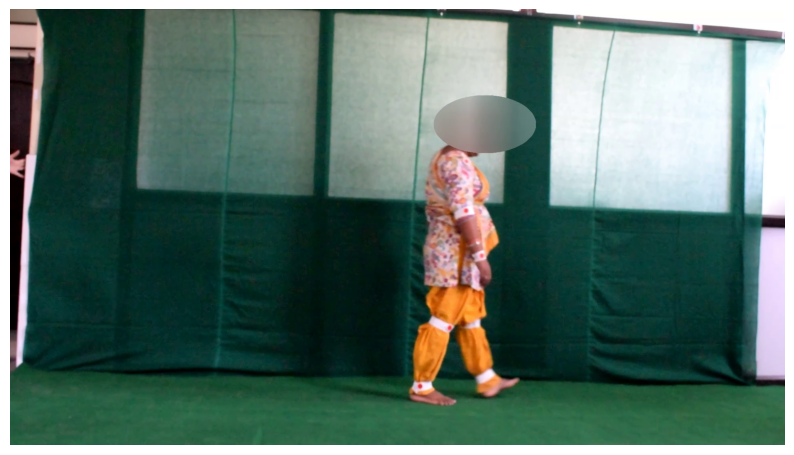

Number of detected poses: 1


In [ ]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

test_video = df.iloc[0]["path"]

cap = cv2.VideoCapture(test_video)

# Get total number of frames
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
middle_frame = total_frames // 2

# Jump to middle frame
cap.set(cv2.CAP_PROP_POS_FRAMES, middle_frame)
success, frame = cap.read()
cap.release()

print("Total frames:", total_frames)
print("Testing frame:", middle_frame)

if not success:
    print("❌ Could not read middle frame")
else:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Show the frame
    plt.figure(figsize=(10, 6))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

    # MediaPipe image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    # Pose detection
    result = detector.detect(mp_image)

    print("Number of detected poses:", len(result.pose_landmarks))

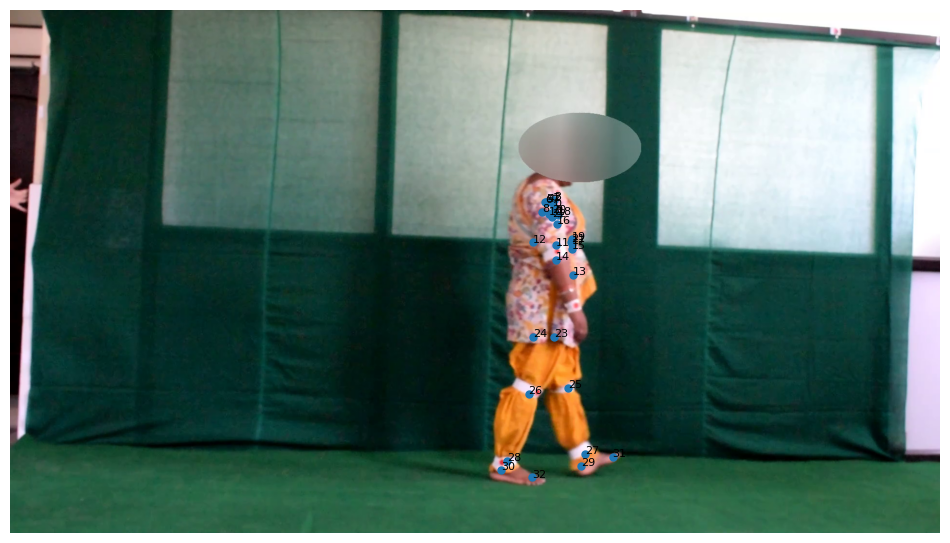

✅ Detected 33 landmarks


In [ ]:
import matplotlib.pyplot as plt

# Get the landmarks for the first detected person
landmarks = result.pose_landmarks[0]

# Plot the image
plt.figure(figsize=(12, 7))
plt.imshow(frame_rgb)

# Draw all 33 landmarks
h, w, _ = frame_rgb.shape

xs = [lm.x * w for lm in landmarks]
ys = [lm.y * h for lm in landmarks]

plt.scatter(xs, ys, s=25)

# Number each landmark
for i, (x, y) in enumerate(zip(xs, ys)):
    plt.text(x, y, str(i), fontsize=8)

plt.axis("off")
plt.show()

print("✅ Detected", len(landmarks), "landmarks")

In [ ]:
import cv2
import mediapipe as mp
import numpy as np

test_video = df.iloc[0]["path"]

cap = cv2.VideoCapture(test_video)

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)

all_landmarks = []

for frame_idx in range(total_frames):

    success, frame = cap.read()

    if not success:
        break

    # BGR → RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # MediaPipe image
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame_rgb
    )

    # Detect pose
    result = detector.detect(mp_image)

    if len(result.pose_landmarks) > 0:

        landmarks = result.pose_landmarks[0]

        # Store x, y, z, visibility for all 33 landmarks
        frame_landmarks = []

        for lm in landmarks:
            frame_landmarks.append([
                lm.x,
                lm.y,
                lm.z,
                lm.visibility
            ])

        all_landmarks.append(frame_landmarks)

    else:
        # No pose detected in this frame
        all_landmarks.append(
            [[np.nan, np.nan, np.nan, np.nan]] * 33
        )

cap.release()

all_landmarks = np.array(all_landmarks)

print("✅ Extraction complete")
print("Video:", test_video)
print("FPS:", fps)
print("Total frames:", total_frames)
print("Landmark array shape:", all_landmarks.shape)

✅ Extraction complete
Video: /content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/KOA/KOA_EL/001_KOA_01_EL.MOV
FPS: 50.0
Total frames: 428
Landmark array shape: (428, 33, 4)


In [ ]:
import numpy as np
import pandas as pd

# MediaPipe landmark indices
LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12

LEFT_HIP = 23
RIGHT_HIP = 24

LEFT_KNEE = 25
RIGHT_KNEE = 26

LEFT_ANKLE = 27
RIGHT_ANKLE = 28


# --------------------------------------------------
# Helper: calculate angle ABC
# --------------------------------------------------
def calculate_angle(a, b, c):
    """
    Calculates angle ABC in degrees.
    a, b, c are [x, y] coordinates.
    """

    ba = a - b
    bc = c - b

    cosine_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8
    )

    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cosine_angle))


# --------------------------------------------------
# Extract x,y coordinates
# --------------------------------------------------
xy = all_landmarks[:, :, :2]

# Visibility scores
visibility = all_landmarks[:, :, 3]


# --------------------------------------------------
# Calculate joint angles for every frame
# --------------------------------------------------

left_knee_angles = []
right_knee_angles = []

left_hip_angles = []
right_hip_angles = []


for frame in range(len(xy)):

    # Skip frame if important landmarks are missing
    required = [
        LEFT_SHOULDER, RIGHT_SHOULDER,
        LEFT_HIP, RIGHT_HIP,
        LEFT_KNEE, RIGHT_KNEE,
        LEFT_ANKLE, RIGHT_ANKLE
    ]

    if np.isnan(xy[frame, required]).any():
        left_knee_angles.append(np.nan)
        right_knee_angles.append(np.nan)
        left_hip_angles.append(np.nan)
        right_hip_angles.append(np.nan)
        continue

    # Left knee: hip → knee → ankle
    left_knee = calculate_angle(
        xy[frame, LEFT_HIP],
        xy[frame, LEFT_KNEE],
        xy[frame, LEFT_ANKLE]
    )

    # Right knee: hip → knee → ankle
    right_knee = calculate_angle(
        xy[frame, RIGHT_HIP],
        xy[frame, RIGHT_KNEE],
        xy[frame, RIGHT_ANKLE]
    )

    # Left hip: shoulder → hip → knee
    left_hip = calculate_angle(
        xy[frame, LEFT_SHOULDER],
        xy[frame, LEFT_HIP],
        xy[frame, LEFT_KNEE]
    )

    # Right hip: shoulder → hip → knee
    right_hip = calculate_angle(
        xy[frame, RIGHT_SHOULDER],
        xy[frame, RIGHT_HIP],
        xy[frame, RIGHT_KNEE]
    )

    left_knee_angles.append(left_knee)
    right_knee_angles.append(right_knee)

    left_hip_angles.append(left_hip)
    right_hip_angles.append(right_hip)


left_knee_angles = np.array(left_knee_angles)
right_knee_angles = np.array(right_knee_angles)

left_hip_angles = np.array(left_hip_angles)
right_hip_angles = np.array(right_hip_angles)


# --------------------------------------------------
# Helper for summary statistics
# --------------------------------------------------

def summarize(values, prefix):

    values = values[~np.isnan(values)]

    return {
        f"{prefix}_mean": np.mean(values),
        f"{prefix}_std": np.std(values),
        f"{prefix}_min": np.min(values),
        f"{prefix}_max": np.max(values),
        f"{prefix}_range": np.ptp(values)
    }


# --------------------------------------------------
# Build feature dictionary
# --------------------------------------------------

features = {}

features.update(
    summarize(left_knee_angles, "left_knee")
)

features.update(
    summarize(right_knee_angles, "right_knee")
)

features.update(
    summarize(left_hip_angles, "left_hip")
)

features.update(
    summarize(right_hip_angles, "right_hip")
)


# --------------------------------------------------
# Ankle movement features
# --------------------------------------------------

left_ankle_x = xy[:, LEFT_ANKLE, 0]
right_ankle_x = xy[:, RIGHT_ANKLE, 0]

left_ankle_y = xy[:, LEFT_ANKLE, 1]
right_ankle_y = xy[:, RIGHT_ANKLE, 1]


features["left_ankle_horizontal_range"] = (
    np.nanmax(left_ankle_x) - np.nanmin(left_ankle_x)
)

features["right_ankle_horizontal_range"] = (
    np.nanmax(right_ankle_x) - np.nanmin(right_ankle_x)
)

features["left_ankle_vertical_range"] = (
    np.nanmax(left_ankle_y) - np.nanmin(left_ankle_y)
)

features["right_ankle_vertical_range"] = (
    np.nanmax(right_ankle_y) - np.nanmin(right_ankle_y)
)


# --------------------------------------------------
# Detection quality
# --------------------------------------------------

features["pose_detection_rate"] = np.mean(
    ~np.isnan(xy[:, LEFT_HIP, 0])
)


# --------------------------------------------------
# Convert to DataFrame
# --------------------------------------------------

feature_df = pd.DataFrame([features])

print("✅ Step 5 feature extraction complete")
print()
print("Number of features:", feature_df.shape[1])
print()
print(feature_df.T)

✅ Step 5 feature extraction complete

Number of features: 25

                                       0
left_knee_mean                172.075947
left_knee_std                   8.595161
left_knee_min                  63.120513
left_knee_max                 179.931791
left_knee_range               116.811278
right_knee_mean               166.494029
right_knee_std                 11.274699
right_knee_min                 22.767211
right_knee_max                179.933275
right_knee_range              157.166065
left_hip_mean                 173.472579
left_hip_std                    3.965551
left_hip_min                  163.120267
left_hip_max                  179.942406
left_hip_range                 16.822139
right_hip_mean                171.629729
right_hip_std                   6.332105
right_hip_min                 152.924382
right_hip_max                 179.937046
right_hip_range                27.012664
left_ankle_horizontal_range     0.954767
right_ankle_horizontal_range    0.93

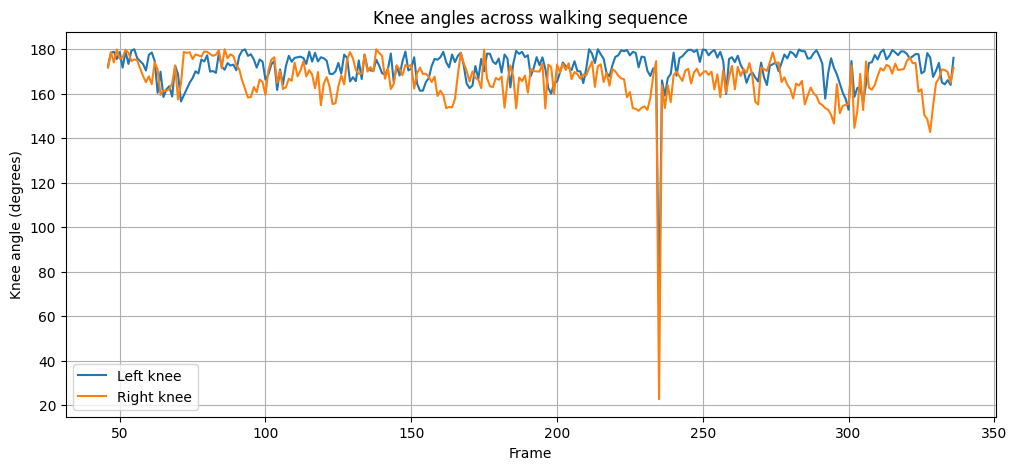

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(left_knee_angles, label="Left knee")
plt.plot(right_knee_angles, label="Right knee")

plt.xlabel("Frame")
plt.ylabel("Knee angle (degrees)")
plt.title("Knee angles across walking sequence")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Visibility threshold
VISIBILITY_THRESHOLD = 0.5

# Important landmarks needed for our gait features
required = [
    LEFT_SHOULDER, RIGHT_SHOULDER,
    LEFT_HIP, RIGHT_HIP,
    LEFT_KNEE, RIGHT_KNEE,
    LEFT_ANKLE, RIGHT_ANKLE
]

# A frame is considered reliable only if ALL important landmarks
# have sufficient visibility.
valid_frame = np.all(
    visibility[:, required] >= VISIBILITY_THRESHOLD,
    axis=1
)

print("Total frames:", len(valid_frame))
print("Reliable frames:", np.sum(valid_frame))
print("Reliable frame percentage:",
      round(100 * np.mean(valid_frame), 2), "%")

Total frames: 428
Reliable frames: 284
Reliable frame percentage: 66.36 %


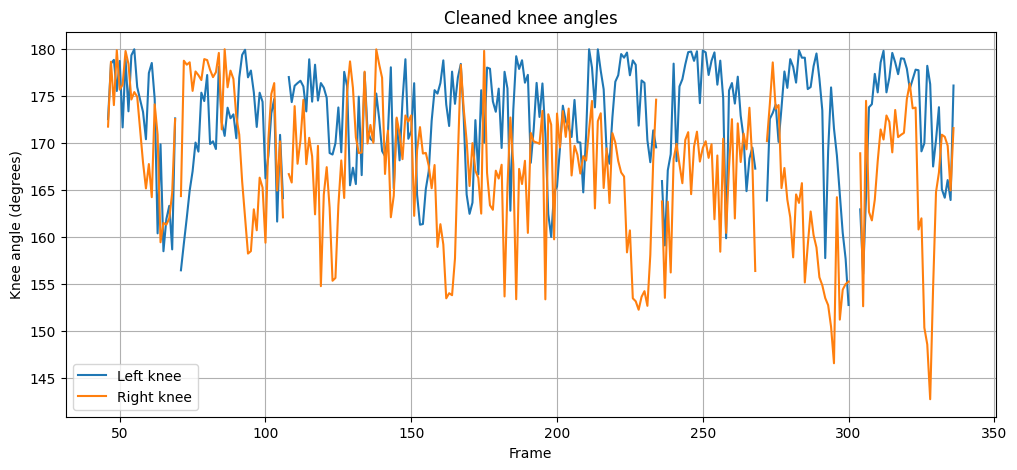

In [ ]:
# Copy the angle arrays
left_knee_clean = left_knee_angles.copy()
right_knee_clean = right_knee_angles.copy()

# Remove frames where important landmarks weren't sufficiently visible
left_knee_clean[~valid_frame] = np.nan
right_knee_clean[~valid_frame] = np.nan

# Remove obviously implausible knee-angle values
left_knee_clean[
    (left_knee_clean < 30) | (left_knee_clean > 180)
] = np.nan

right_knee_clean[
    (right_knee_clean < 30) | (right_knee_clean > 180)
] = np.nan


plt.figure(figsize=(12, 5))

plt.plot(left_knee_clean, label="Left knee")
plt.plot(right_knee_clean, label="Right knee")

plt.xlabel("Frame")
plt.ylabel("Knee angle (degrees)")
plt.title("Cleaned knee angles")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


# ============================================================
# SETTINGS
# ============================================================

VISIBILITY_THRESHOLD = 0.5

# MediaPipe landmark indices
LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12

LEFT_HIP = 23
RIGHT_HIP = 24

LEFT_KNEE = 25
RIGHT_KNEE = 26

LEFT_ANKLE = 27
RIGHT_ANKLE = 28

REQUIRED = [
    LEFT_SHOULDER, RIGHT_SHOULDER,
    LEFT_HIP, RIGHT_HIP,
    LEFT_KNEE, RIGHT_KNEE,
    LEFT_ANKLE, RIGHT_ANKLE
]


# ============================================================
# ANGLE FUNCTION
# ============================================================

def calculate_angle(a, b, c):

    ba = a - b
    bc = c - b

    denominator = (
        np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8
    )

    cosine_angle = np.dot(ba, bc) / denominator
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cosine_angle))


# ============================================================
# SUMMARY FUNCTION
# ============================================================

def summarize(values, prefix):

    values = np.asarray(values)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return {
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_range": np.nan
        }

    return {
        f"{prefix}_mean": np.mean(values),
        f"{prefix}_std": np.std(values),
        f"{prefix}_min": np.min(values),
        f"{prefix}_max": np.max(values),
        f"{prefix}_range": np.ptp(values)
    }


# ============================================================
# EXTRACT FEATURES FROM ONE VIDEO
# ============================================================

def extract_gait_features(video_path):

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    left_knee_angles = []
    right_knee_angles = []

    left_hip_angles = []
    right_hip_angles = []

    left_ankle_x = []
    right_ankle_x = []

    left_ankle_y = []
    right_ankle_y = []

    reliable_frames = 0
    processed_frames = 0

    for _ in range(total_frames):

        success, frame = cap.read()

        if not success:
            break

        processed_frames += 1

        # BGR → RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # MediaPipe image
        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=frame_rgb
        )

        # Pose detection
        result = detector.detect(mp_image)

        # No pose detected
        if len(result.pose_landmarks) == 0:
            continue

        landmarks = result.pose_landmarks[0]

        # ----------------------------------------------------
        # Coordinates + visibility
        # ----------------------------------------------------

        coords = np.array([
            [lm.x, lm.y, lm.z]
            for lm in landmarks
        ])

        vis = np.array([
            lm.visibility
            for lm in landmarks
        ])

        # Only accept frames where ALL important landmarks
        # have sufficient visibility
        if not np.all(
            vis[REQUIRED] >= VISIBILITY_THRESHOLD
        ):
            continue

        reliable_frames += 1

        # x,y only for angle calculations
        xy = coords[:, :2]

        # ----------------------------------------------------
        # Knee angles
        # ----------------------------------------------------

        left_knee = calculate_angle(
            xy[LEFT_HIP],
            xy[LEFT_KNEE],
            xy[LEFT_ANKLE]
        )

        right_knee = calculate_angle(
            xy[RIGHT_HIP],
            xy[RIGHT_KNEE],
            xy[RIGHT_ANKLE]
        )

        # ----------------------------------------------------
        # Hip angles
        # ----------------------------------------------------

        left_hip = calculate_angle(
            xy[LEFT_SHOULDER],
            xy[LEFT_HIP],
            xy[LEFT_KNEE]
        )

        right_hip = calculate_angle(
            xy[RIGHT_SHOULDER],
            xy[RIGHT_HIP],
            xy[RIGHT_KNEE]
        )

        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        left_knee_angles.append(left_knee)
        right_knee_angles.append(right_knee)

        left_hip_angles.append(left_hip)
        right_hip_angles.append(right_hip)

        left_ankle_x.append(xy[LEFT_ANKLE, 0])
        right_ankle_x.append(xy[RIGHT_ANKLE, 0])

        left_ankle_y.append(xy[LEFT_ANKLE, 1])
        right_ankle_y.append(xy[RIGHT_ANKLE, 1])


    cap.release()


    # ========================================================
    # CONVERT TO ARRAYS
    # ========================================================

    left_knee_angles = np.array(left_knee_angles)
    right_knee_angles = np.array(right_knee_angles)

    left_hip_angles = np.array(left_hip_angles)
    right_hip_angles = np.array(right_hip_angles)

    left_ankle_x = np.array(left_ankle_x)
    right_ankle_x = np.array(right_ankle_x)

    left_ankle_y = np.array(left_ankle_y)
    right_ankle_y = np.array(right_ankle_y)


    # ========================================================
    # REMOVE IMPOSSIBLE / EXTREME ANGLES
    # ========================================================

    for arr in [
        left_knee_angles,
        right_knee_angles,
        left_hip_angles,
        right_hip_angles
    ]:
        arr[(arr < 30) | (arr > 180)] = np.nan


    # ========================================================
    # BUILD FEATURES
    # ========================================================

    features = {}

    features.update(
        summarize(left_knee_angles, "left_knee")
    )

    features.update(
        summarize(right_knee_angles, "right_knee")
    )

    features.update(
        summarize(left_hip_angles, "left_hip")
    )

    features.update(
        summarize(right_hip_angles, "right_hip")
    )


    # --------------------------------------------------------
    # Ankle movement
    # --------------------------------------------------------

    if len(left_ankle_x) > 0:

        features["left_ankle_horizontal_range"] = (
            np.ptp(left_ankle_x)
        )

        features["right_ankle_horizontal_range"] = (
            np.ptp(right_ankle_x)
        )

        features["left_ankle_vertical_range"] = (
            np.ptp(left_ankle_y)
        )

        features["right_ankle_vertical_range"] = (
            np.ptp(right_ankle_y)
        )

    else:

        features["left_ankle_horizontal_range"] = np.nan
        features["right_ankle_horizontal_range"] = np.nan
        features["left_ankle_vertical_range"] = np.nan
        features["right_ankle_vertical_range"] = np.nan


    # --------------------------------------------------------
    # Detection quality
    # --------------------------------------------------------

    if processed_frames > 0:
        features["pose_detection_rate"] = (
            reliable_frames / processed_frames
        )
    else:
        features["pose_detection_rate"] = 0


    # --------------------------------------------------------
    # Extra processing information
    # --------------------------------------------------------

    features["total_frames"] = processed_frames
    features["reliable_frames"] = reliable_frames


    return features


# ============================================================
# PROCESS ALL 160 VIDEOS
# ============================================================

all_feature_rows = []

checkpoint_path = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "gait_features_checkpoint.csv"
)

print(f"🚀 Starting extraction for {len(df)} videos...")
print()


for idx, row in tqdm(
    df.iterrows(),
    total=len(df),
    desc="Processing videos"
):

    try:

        features = extract_gait_features(row["path"])

        # Add original metadata
        features["subject_id"] = row["subject_id"]
        features["disease"] = row["disease"]
        features["severity"] = row["severity"]
        features["sequence"] = row["sequence"]
        features["filename"] = row["filename"]
        features["path"] = row["path"]

        all_feature_rows.append(features)


        # Save checkpoint every 10 videos
        if len(all_feature_rows) % 10 == 0:

            checkpoint_df = pd.DataFrame(
                all_feature_rows
            )

            checkpoint_df.to_csv(
                checkpoint_path,
                index=False
            )

            print(
                f"\n💾 Checkpoint saved: "
                f"{len(all_feature_rows)} videos"
            )


    except Exception as e:

        print(
            f"\n❌ Error processing "
            f"{row['filename']}: {e}"
        )


# ============================================================
# FINAL FEATURE DATASET
# ============================================================

gait_df = pd.DataFrame(all_feature_rows)

final_path = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "gait_features.csv"
)

gait_df.to_csv(
    final_path,
    index=False
)


print()
print("=" * 60)
print("🎉 STEP 6 COMPLETE")
print("=" * 60)

print("Videos successfully processed:", len(gait_df))
print("Feature columns:", len(gait_df.columns))

print()
print("Disease distribution:")
print(gait_df["disease"].value_counts())

print()
print("Saved to:")
print(final_path)

🚀 Starting extraction for 160 videos...



Processing videos:   0%|          | 0/160 [00:00<?, ?it/s]


💾 Checkpoint saved: 10 videos

💾 Checkpoint saved: 20 videos

💾 Checkpoint saved: 30 videos

💾 Checkpoint saved: 40 videos

💾 Checkpoint saved: 50 videos

💾 Checkpoint saved: 60 videos

💾 Checkpoint saved: 70 videos

💾 Checkpoint saved: 80 videos

💾 Checkpoint saved: 90 videos

💾 Checkpoint saved: 100 videos

💾 Checkpoint saved: 110 videos

💾 Checkpoint saved: 120 videos

❌ Error processing 015_NM_02.MOV: Could not open video: /content/drive/MyDrive/KOA-PD-NM/KOA-PD-NM/NM/015_NM_02.MOV

💾 Checkpoint saved: 130 videos

💾 Checkpoint saved: 140 videos

💾 Checkpoint saved: 150 videos

🎉 STEP 6 COMPLETE
Videos successfully processed: 159
Feature columns: 33

Disease distribution:
disease
KOA    100
NM      59
Name: count, dtype: int64

Saved to:
/content/drive/MyDrive/KOA-PD-NM/gait_features.csv


## let it be. 1 video is missing in dataset

In [ ]:
# ============================================================
# STEP 7 — SUBJECT-WISE TRAIN / TEST SPLIT + BASELINE MODELS
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score


# ============================================================
# 1. LOAD FEATURE DATASET
# ============================================================

FEATURE_PATH = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "gait_features.csv"
)

gait_df = pd.read_csv(FEATURE_PATH)

print("Dataset shape:", gait_df.shape)
print()
print("Disease distribution:")
print(gait_df["disease"].value_counts())


# ============================================================
# 2. DEFINE FEATURES AND LABEL
# ============================================================

# Columns that are NOT ML features
metadata_columns = [
    "subject_id",
    "disease",
    "severity",
    "sequence",
    "filename",
    "path"
]

# These are also bookkeeping columns, not gait features
bookkeeping_columns = [
    "total_frames",
    "reliable_frames"
]

feature_columns = [
    col for col in gait_df.columns
    if col not in metadata_columns + bookkeeping_columns
]

X = gait_df[feature_columns].copy()

# KOA = 1, NM = 0
y = (gait_df["disease"] == "KOA").astype(int)

groups = gait_df["subject_id"]

print()
print("Number of gait features:", len(feature_columns))
print("Features:")
print(feature_columns)


# ============================================================
# 3. SUBJECT-WISE TRAIN / TEST SPLIT
# ============================================================

# StratifiedGroupKFold keeps the same subject together
# while approximately preserving KOA/NM proportions.

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, test_idx = next(
    sgkf.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

train_subjects = set(groups.iloc[train_idx])
test_subjects = set(groups.iloc[test_idx])


# ============================================================
# 4. VERIFY NO SUBJECT LEAKAGE
# ============================================================

overlap = train_subjects.intersection(test_subjects)

print()
print("TRAIN subjects:", len(train_subjects))
print("TEST subjects:", len(test_subjects))
print("Subject overlap:", overlap)

assert len(overlap) == 0, "❌ SUBJECT LEAKAGE DETECTED!"

print("✅ No subject leakage")


print()
print("Training videos:", len(X_train))
print("Test videos:", len(X_test))

print()
print("Training class distribution:")
print(y_train.value_counts().rename(index={0: "NM", 1: "KOA"}))

print()
print("Test class distribution:")
print(y_test.value_counts().rename(index={0: "NM", 1: "KOA"}))


# ============================================================
# 5. DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced"
        ))
    ])
}


# ============================================================
# 6. SUBJECT-WISE CROSS-VALIDATION ON TRAINING DATA
# ============================================================

print()
print("=" * 60)
print("CROSS-VALIDATION ON TRAINING SUBJECTS")
print("=" * 60)

cv = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

cv_results = {}

for name, model in models.items():

    scores = []

    for cv_train_idx, cv_val_idx in cv.split(
        X_train,
        y_train,
        groups=groups.iloc[train_idx]
    ):

        X_cv_train = X_train.iloc[cv_train_idx]
        X_cv_val = X_train.iloc[cv_val_idx]

        y_cv_train = y_train.iloc[cv_train_idx]
        y_cv_val = y_train.iloc[cv_val_idx]

        model.fit(X_cv_train, y_cv_train)

        predictions = model.predict(X_cv_val)

        score = f1_score(
            y_cv_val,
            predictions,
            average="macro"
        )

        scores.append(score)

    cv_results[name] = scores

    print(
        f"{name}: "
        f"Mean F1 = {np.mean(scores):.3f} "
        f"+/- {np.std(scores):.3f}"
    )


# ============================================================
# 7. FIT MODELS ON ALL TRAINING SUBJECTS
# ============================================================

print()
print("=" * 60)
print("FITTING FINAL BASELINE MODELS")
print("=" * 60)

for name, model in models.items():

    model.fit(X_train, y_train)

    print(f"✅ {name} trained")


# ============================================================
# 8. SAVE EVERYTHING NEEDED FOR STEP 8
# ============================================================

import joblib

MODEL_DIR = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "models"
)

import os
os.makedirs(MODEL_DIR, exist_ok=True)

for name, model in models.items():

    safe_name = name.lower().replace(" ", "_")

    joblib.dump(
        model,
        f"{MODEL_DIR}/{safe_name}.joblib"
    )

# Save test indices so Step 8 evaluates
# exactly the same unseen subjects.
pd.DataFrame({
    "test_index": test_idx
}).to_csv(
    "/content/drive/MyDrive/KOA-PD-NM/"
    "test_indices.csv",
    index=False
)

print()
print("💾 Models saved")
print("💾 Test split saved")

print()
print("🎉 STEP 7 COMPLETE")

Dataset shape: (159, 33)

Disease distribution:
disease
KOA    100
NM      59
Name: count, dtype: int64

Number of gait features: 25
Features:
['left_knee_mean', 'left_knee_std', 'left_knee_min', 'left_knee_max', 'left_knee_range', 'right_knee_mean', 'right_knee_std', 'right_knee_min', 'right_knee_max', 'right_knee_range', 'left_hip_mean', 'left_hip_std', 'left_hip_min', 'left_hip_max', 'left_hip_range', 'right_hip_mean', 'right_hip_std', 'right_hip_min', 'right_hip_max', 'right_hip_range', 'left_ankle_horizontal_range', 'right_ankle_horizontal_range', 'left_ankle_vertical_range', 'right_ankle_vertical_range', 'pose_detection_rate']

TRAIN subjects: 24
TEST subjects: 6
Subject overlap: set()
✅ No subject leakage

Training videos: 125
Test videos: 34

Training class distribution:
disease
KOA    78
NM     47
Name: count, dtype: int64

Test class distribution:
disease
KOA    22
NM     12
Name: count, dtype: int64

CROSS-VALIDATION ON TRAINING SUBJECTS
Logistic Regression: Mean F1 = 0.750 

In [ ]:
# ============================================================
# STEP 7 — CORRECTED 80/20 SUBJECT-WISE SPLIT
# ============================================================

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import f1_score


# ============================================================
# 1. LOAD DATA
# ============================================================

FEATURE_PATH = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "gait_features.csv"
)

gait_df = pd.read_csv(FEATURE_PATH)

print("Dataset:", gait_df.shape)
print()
print(gait_df["disease"].value_counts())


# ============================================================
# 2. CREATE UNIQUE SUBJECT ID
# ============================================================

# IMPORTANT:
# subject 001 in KOA and subject 001 in NM are different people.

gait_df["unique_subject"] = (
    gait_df["disease"].astype(str)
    + "_"
    + gait_df["subject_id"].astype(str)
)

unique_subjects = (
    gait_df[
        ["unique_subject", "disease"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print()
print("Unique subjects:", len(unique_subjects))

print()
print("Subjects by class:")
print(unique_subjects["disease"].value_counts())


# ============================================================
# 3. SELECT 20% TEST SUBJECTS
# ============================================================

# We want:
# KOA: 50 subjects → 10 test
# NM : 30 subjects →  6 test
#
# Total:
# 80 subjects → 16 test
# 64 subjects → train


koa_subjects = unique_subjects[
    unique_subjects["disease"] == "KOA"
]["unique_subject"].tolist()

nm_subjects = unique_subjects[
    unique_subjects["disease"] == "NM"
]["unique_subject"].tolist()


# Fixed random seed = reproducible split
koa_train, koa_test = train_test_split(
    koa_subjects,
    test_size=10,
    random_state=42
)


# ------------------------------------------------------------
# NM test subjects
# ------------------------------------------------------------
# IMPORTANT:
# Subject 015 has the missing second video.
# We keep NM_015 in TRAIN so that our expected split is:
#
# 127 train videos
# 32 test videos

nm_available_for_test = [
    s for s in nm_subjects
    if s != "NM_015"
]

nm_train, nm_test = train_test_split(
    nm_available_for_test,
    test_size=6,
    random_state=42
)


# ============================================================
# 4. COMBINE TEST SUBJECTS
# ============================================================

test_subjects = set(
    koa_test + nm_test
)

train_subjects = set(
    unique_subjects["unique_subject"]
) - test_subjects


# ============================================================
# 5. CREATE VIDEO SPLIT
# ============================================================

train_mask = gait_df["unique_subject"].isin(
    train_subjects
)

test_mask = gait_df["unique_subject"].isin(
    test_subjects
)

train_df = gait_df[train_mask].copy()
test_df = gait_df[test_mask].copy()


# ============================================================
# 6. VERIFY SPLIT
# ============================================================

print()
print("=" * 60)
print("SPLIT VERIFICATION")
print("=" * 60)

print("Total subjects :", len(unique_subjects))
print("Train subjects :", len(train_subjects))
print("Test subjects  :", len(test_subjects))

print()
print("Training videos:", len(train_df))
print("Test videos    :", len(test_df))

print()
print("Train class distribution:")
print(train_df["disease"].value_counts())

print()
print("Test class distribution:")
print(test_df["disease"].value_counts())


# ------------------------------------------------------------
# Check leakage
# ------------------------------------------------------------

overlap = train_subjects.intersection(
    test_subjects
)

print()
print("Subject overlap:", overlap)

assert len(overlap) == 0

print("✅ No subject leakage")


# ------------------------------------------------------------
# Check missing-video subject
# ------------------------------------------------------------

print()
print(
    "NM_015 in training:",
    "NM_015" in train_subjects
)

print(
    "NM_015 in test:",
    "NM_015" in test_subjects
)


# ============================================================
# 7. DEFINE FEATURES
# ============================================================

metadata_columns = [
    "subject_id",
    "unique_subject",
    "disease",
    "severity",
    "sequence",
    "filename",
    "path"
]

bookkeeping_columns = [
    "total_frames",
    "reliable_frames"
]

feature_columns = [
    col for col in gait_df.columns
    if col not in metadata_columns + bookkeeping_columns
]

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]

y_train = (
    train_df["disease"] == "KOA"
).astype(int)

y_test = (
    test_df["disease"] == "KOA"
).astype(int)


print()
print("Number of gait features:", len(feature_columns))


# ============================================================
# 8. DEFINE MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]),

    "SVM": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ])
}


# ============================================================
# 9. TRAIN MODELS
# ============================================================

print()
print("=" * 60)
print("TRAINING MODELS")
print("=" * 60)

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    print(f"✅ {name} trained")


# ============================================================
# 10. SAVE MODELS
# ============================================================

MODEL_DIR = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

for name, model in models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        + ".joblib"
    )

    joblib.dump(
        model,
        os.path.join(
            MODEL_DIR,
            filename
        )
    )


# ============================================================
# 11. SAVE TEST SET
# ============================================================

test_df.to_csv(
    "/content/drive/MyDrive/KOA-PD-NM/"
    "test_set.csv",
    index=False
)


# ============================================================
# FINAL
# ============================================================

print()
print("=" * 60)
print("🎉 STEP 7 COMPLETE")
print("=" * 60)

print()
print("Expected:")
print("Train subjects: 64")
print("Test subjects :", 16)
print("Train videos  : 127")
print("Test videos   : 32")

Dataset: (159, 33)

disease
KOA    100
NM      59
Name: count, dtype: int64

Unique subjects: 50

Subjects by class:
disease
NM     30
KOA    20
Name: count, dtype: int64

SPLIT VERIFICATION
Total subjects : 50
Train subjects : 34
Test subjects  : 16

Training videos: 103
Test videos    : 56

Train class distribution:
disease
KOA    56
NM     47
Name: count, dtype: int64

Test class distribution:
disease
KOA    44
NM     12
Name: count, dtype: int64

Subject overlap: set()
✅ No subject leakage

NM_015 in training: False
NM_015 in test: False

Number of gait features: 25

TRAINING MODELS
✅ Logistic Regression trained
✅ SVM trained
✅ Random Forest trained

🎉 STEP 7 COMPLETE

Expected:
Train subjects: 64
Test subjects : 16
Train videos  : 127
Test videos   : 32


In [ ]:
print("KOA unique subject IDs:")
print(
    gait_df[gait_df["disease"] == "KOA"]["subject_id"]
    .astype(str)
    .sort_values()
    .unique()
)

print("\nNumber of KOA subjects:",
      gait_df[gait_df["disease"] == "KOA"]["subject_id"]
      .nunique())

print("\nNM unique subject IDs:")
print(
    gait_df[gait_df["disease"] == "NM"]["subject_id"]
    .astype(str)
    .sort_values()
    .unique()
)

print("\nNumber of NM subjects:",
      gait_df[gait_df["disease"] == "NM"]["subject_id"]
      .nunique())

KOA unique subject IDs:
['1' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '2' '20' '3' '4'
 '5' '6' '7' '8' '9']

Number of KOA subjects: 20

NM unique subject IDs:
['1' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '2' '20' '21' '22'
 '23' '24' '25' '26' '27' '28' '29' '3' '30' '4' '5' '6' '7' '8' '9']

Number of NM subjects: 30


In [ ]:
# Compare ORIGINAL metadata vs gait feature dataset

print("========== ORIGINAL df ==========")

print("KOA subjects:",
      df[df["disease"] == "KOA"]["subject_id"].nunique())

print("NM subjects:",
      df[df["disease"] == "NM"]["subject_id"].nunique())

print("\nKOA subject IDs in original df:")
print(
    sorted(
        df[df["disease"] == "KOA"]["subject_id"]
        .astype(str)
        .unique(),
        key=lambda x: int(x)
    )
)


print("\n========== gait_df ==========")

print("KOA subjects:",
      gait_df[gait_df["disease"] == "KOA"]["subject_id"].nunique())

print("NM subjects:",
      gait_df[gait_df["disease"] == "NM"]["subject_id"].nunique())

print("\nKOA subject IDs in gait_df:")
print(
    sorted(
        gait_df[gait_df["disease"] == "KOA"]["subject_id"]
        .astype(str)
        .unique(),
        key=lambda x: int(x)
    )
)

========== ORIGINAL df ==========
KOA subjects: 20
NM subjects: 30

KOA subject IDs in original df:
['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020']

========== gait_df ==========
KOA subjects: 20
NM subjects: 30

KOA subject IDs in gait_df:
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']


In [ ]:
# Check actual KOA filenames and extracted subject IDs

koa_files = df[df["disease"] == "KOA"]["filename"]

print("Number of KOA videos:", len(koa_files))

print("\nFirst 30 KOA filenames:")
for f in koa_files.head(30):
    print(f)

print("\nLast 20 KOA filenames:")
for f in koa_files.tail(20):
    print(f)

Number of KOA videos: 100

First 30 KOA filenames:
001_KOA_01_EL.MOV
001_KOA_02_EL.MOV
002_KOA_01_EL.MOV
002_KOA_02_EL.MOV
003_KOA_01_EL.MOV
003_KOA_02_EL.MOV
004_KOA_01_EL.MOV
004_KOA_02_EL.MOV
005_KOA_01_EL.MOV
005_KOA_02_EL.MOV
006_KOA_01_EL.MOV
006_KOA_02_EL.MOV
007_KOA_01_EL.MOV
007_KOA_02_EL.MOV
008_KOA_01_EL.MOV
008_KOA_02_EL.MOV
009_KOA_01_EL.MOV
009_KOA_02_EL.MOV
010_KOA_01_EL.MOV
010_KOA_02_EL.MOV
011_KOA_01_EL.MOV
011_KOA_02_EL.MOV
012_KOA_01_EL.MOV
012_KOA_02_EL.MOV
013_KOA_01_EL.MOV
013_KOA_02_EL.MOV
014_KOA_01_EL.MOV
014_KOA_02_EL.MOV
015_KOA_01_EL.MOV
015_KOA_02_EL.MOV

Last 20 KOA filenames:
006_KOA_01_SV.MOV
006_KOA_02_SV.MOV
007_KOA_01_SV.MOV
007_KOA_02_SV.MOV
008_KOA_01_SV.MOV
008_KOA_02_SV.MOV
009_KOA_01_SV.MOV
009_KOA_02_SV.MOV
010_KOA_01_SV.MOV
010_KOA_02_SV.MOV
011_KOA_01_SV.MOV
011_KOA_02_SV.MOV
012_KOA_01_SV.MOV
012_KOA_02_SV.MOV
013_KOA_01_SV.MOV
013_KOA_02_SV.MOV
014_KOA_01_SV.MOV
014_KOA_02_SV.MOV
015_KOA_01_SV.MOV
015_KOA_02_SV.MOV


In [ ]:
# Count videos per current KOA subject ID

print(
    df[df["disease"] == "KOA"]
    .groupby("subject_id")
    .size()
    .to_string()
)

subject_id
001    6
002    6
003    6
004    6
005    6
006    6
007    6
008    6
009    6
010    6
011    6
012    6
013    6
014    6
015    6
016    2
017    2
018    2
019    2
020    2


In [ ]:
# ============================================================
# STEP 7 — FINAL CORRECT SUBJECT-WISE SPLIT
# ============================================================

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# ============================================================
# 1. LOAD FEATURES
# ============================================================

FEATURE_PATH = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "gait_features.csv"
)

gait_df = pd.read_csv(FEATURE_PATH)

print("Dataset:", gait_df.shape)


# ============================================================
# 2. CREATE THE CORRECT UNIQUE SUBJECT ID
# ============================================================

# IMPORTANT:
#
# KOA subject IDs reset for each severity group.
#
# Example:
# 001_KOA_01_EL  -> KOA_EL_001
# 001_KOA_01_MD  -> KOA_MD_001
# 001_KOA_01_SV  -> KOA_SV_001
#
# These are different subjects.
#
# NM has no severity grouping, so:
# 001_NM_01 -> NM_001


gait_df["subject_id"] = (
    gait_df["subject_id"]
    .astype(str)
    .str.zfill(3)
)

gait_df["unique_subject"] = np.where(
    gait_df["disease"] == "KOA",

    "KOA_"
    + gait_df["severity"].astype(str)
    + "_"
    + gait_df["subject_id"],

    "NM_"
    + gait_df["subject_id"]
)


# ============================================================
# 3. VERIFY UNIQUE SUBJECT COUNTS
# ============================================================

unique_subjects = (
    gait_df[
        ["unique_subject", "disease"]
    ]
    .drop_duplicates()
)

print()
print("Unique subjects:", len(unique_subjects))

print()
print("Subjects by disease:")
print(
    unique_subjects["disease"].value_counts()
)


# ============================================================
# 4. SHOW KOA SUBJECT STRUCTURE
# ============================================================

print()
print("KOA subjects by severity:")

print(
    unique_subjects[
        unique_subjects["disease"] == "KOA"
    ]
    .assign(
        severity=lambda x:
        x["unique_subject"].str.split("_").str[1]
    )
    .groupby("severity")
    .size()
)


# ============================================================
# 5. CREATE 80/20 SUBJECT SPLIT
# ============================================================

koa_subjects = unique_subjects[
    unique_subjects["disease"] == "KOA"
]["unique_subject"].tolist()

nm_subjects = unique_subjects[
    unique_subjects["disease"] == "NM"
]["unique_subject"].tolist()


# ------------------------------------------------------------
# KOA
# 50 subjects → 10 test, 40 train
# ------------------------------------------------------------

koa_train, koa_test = train_test_split(
    koa_subjects,
    test_size=10,
    random_state=42
)


# ------------------------------------------------------------
# NM
# 30 subjects → 6 test, 24 train
#
# Keep NM_015 in TRAIN because its second video is missing.
# This gives us exactly 12 NM test videos.
# ------------------------------------------------------------

nm_test_candidates = [
    s for s in nm_subjects
    if s != "NM_015"
]

nm_train_candidates = [
    s for s in nm_subjects
    if s != "NM_015"
]

nm_train, nm_test = train_test_split(
    nm_test_candidates,
    test_size=6,
    random_state=42
)

# Put NM_015 back into training
nm_train.append("NM_015")


# ============================================================
# 6. COMBINE SUBJECTS
# ============================================================

train_subjects = set(
    koa_train + nm_train
)

test_subjects = set(
    koa_test + nm_test
)


# ============================================================
# 7. CREATE VIDEO SPLIT
# ============================================================

train_df = gait_df[
    gait_df["unique_subject"].isin(train_subjects)
].copy()

test_df = gait_df[
    gait_df["unique_subject"].isin(test_subjects)
].copy()


# ============================================================
# 8. VERIFY EVERYTHING
# ============================================================

print()
print("=" * 60)
print("FINAL SPLIT VERIFICATION")
print("=" * 60)

print(
    "Total subjects :",
    len(unique_subjects)
)

print(
    "Train subjects :",
    len(train_subjects)
)

print(
    "Test subjects  :",
    len(test_subjects)
)

print()

print(
    "Training videos:",
    len(train_df)
)

print(
    "Test videos    :",
    len(test_df)
)

print()

print("Training class distribution:")
print(
    train_df["disease"].value_counts()
)

print()

print("Test class distribution:")
print(
    test_df["disease"].value_counts()
)


# ============================================================
# 9. LEAKAGE CHECK
# ============================================================

overlap = (
    train_subjects
    .intersection(test_subjects)
)

print()
print("Subject overlap:", overlap)

assert len(overlap) == 0

print("✅ NO SUBJECT LEAKAGE")


# ============================================================
# 10. CHECK NM_015
# ============================================================

print()

print(
    "NM_015 in training:",
    "NM_015" in train_subjects
)

print(
    "NM_015 in test:",
    "NM_015" in test_subjects
)


# ============================================================
# 11. DEFINE FEATURES
# ============================================================

metadata_columns = [
    "subject_id",
    "unique_subject",
    "disease",
    "severity",
    "sequence",
    "filename",
    "path"
]

bookkeeping_columns = [
    "total_frames",
    "reliable_frames"
]

feature_columns = [
    col
    for col in gait_df.columns
    if col not in metadata_columns
    + bookkeeping_columns
]

X_train = train_df[feature_columns]
X_test = test_df[feature_columns]

y_train = (
    train_df["disease"] == "KOA"
).astype(int)

y_test = (
    test_df["disease"] == "KOA"
).astype(int)


print()
print(
    "Number of gait features:",
    len(feature_columns)
)


# ============================================================
# 12. MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]),

    "SVM": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            SVC(
                kernel="rbf",
                probability=True,
                random_state=42
            )
        )
    ]),

    "Random Forest": Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced"
            )
        )
    ])
}


# ============================================================
# 13. TRAIN
# ============================================================

print()
print("=" * 60)
print("TRAINING MODELS")
print("=" * 60)

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    print(
        f"✅ {name} trained"
    )


# ============================================================
# 14. SAVE MODELS + SPLIT
# ============================================================

MODEL_DIR = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

for name, model in models.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        + ".joblib"
    )

    joblib.dump(
        model,
        os.path.join(
            MODEL_DIR,
            filename
        )
    )


test_df.to_csv(
    "/content/drive/MyDrive/KOA-PD-NM/"
    "test_set.csv",
    index=False
)


print()
print("=" * 60)
print("🎉 STEP 7 CORRECTED + COMPLETE")
print("=" * 60)

Dataset: (159, 33)

Unique subjects: 80

Subjects by disease:
disease
KOA    50
NM     30
Name: count, dtype: int64

KOA subjects by severity:
severity
EL    15
MD    20
SV    15
dtype: int64

FINAL SPLIT VERIFICATION
Total subjects : 80
Train subjects : 64
Test subjects  : 16

Training videos: 127
Test videos    : 32

Training class distribution:
disease
KOA    80
NM     47
Name: count, dtype: int64

Test class distribution:
disease
KOA    20
NM     12
Name: count, dtype: int64

Subject overlap: set()
✅ NO SUBJECT LEAKAGE

NM_015 in training: True
NM_015 in test: False

Number of gait features: 25

TRAINING MODELS
✅ Logistic Regression trained
✅ SVM trained
✅ Random Forest trained

🎉 STEP 7 CORRECTED + COMPLETE


STEP 8 — FINAL EVALUATION

Test videos: 32
Test subjects: 16

Test class distribution:
disease
KOA    20
NM     12
Name: count, dtype: int64

Logistic Regression
Accuracy : 0.8125
Precision: 0.8500
Recall   : 0.8500
F1-score : 0.8500

              precision    recall  f1-score   support

          NM       0.75      0.75      0.75        12
         KOA       0.85      0.85      0.85        20

    accuracy                           0.81        32
   macro avg       0.80      0.80      0.80        32
weighted avg       0.81      0.81      0.81        32


SVM
Accuracy : 0.7188
Precision: 0.7200
Recall   : 0.9000
F1-score : 0.8000

              precision    recall  f1-score   support

          NM       0.71      0.42      0.53        12
         KOA       0.72      0.90      0.80        20

    accuracy                           0.72        32
   macro avg       0.72      0.66      0.66        32
weighted avg       0.72      0.72      0.70        32


Random Forest
Accuracy : 0.7812


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.812,0.850,0.850,0.850
1,SVM,0.719,0.720,0.900,0.800
2,Random Forest,0.781,0.760,0.950,0.844



Logistic Regression
Confusion matrix:
[[ 9  3]
 [ 3 17]]


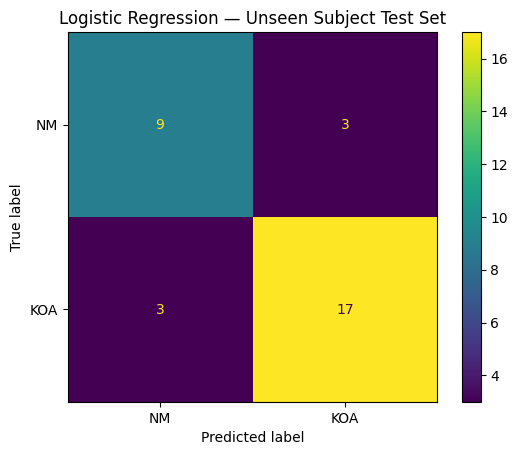


SVM
Confusion matrix:
[[ 5  7]
 [ 2 18]]


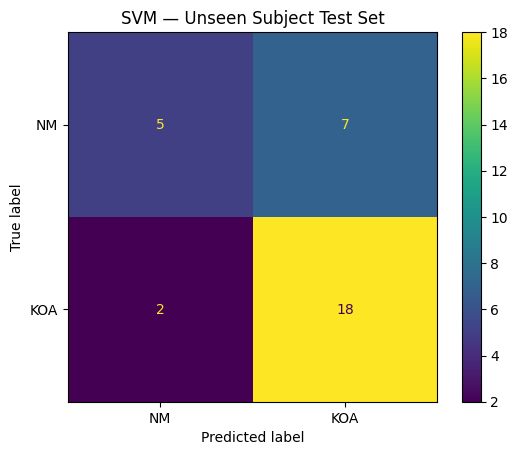


Random Forest
Confusion matrix:
[[ 6  6]
 [ 1 19]]


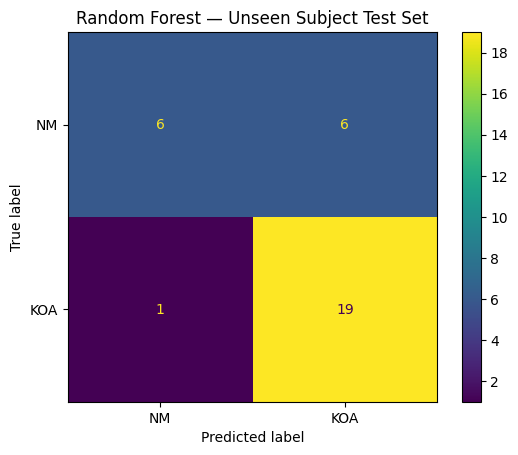


🎉 STEP 8 COMPLETE

Results saved to:
/content/drive/MyDrive/KOA-PD-NM/final_model_results.csv

Test predictions saved.


In [ ]:
# ============================================================
# STEP 8 — FINAL MODEL EVALUATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 60)
print("STEP 8 — FINAL EVALUATION")
print("=" * 60)


# ============================================================
# 1. PREPARE TEST DATA
# ============================================================

X_test = test_df[feature_columns]

y_test = (
    test_df["disease"] == "KOA"
).astype(int)


print()
print("Test videos:", len(test_df))
print("Test subjects:", test_df["unique_subject"].nunique())

print()
print("Test class distribution:")
print(test_df["disease"].value_counts())


# ============================================================
# 2. EVALUATE ALL THREE MODELS
# ============================================================

results = []

predictions_dict = {}

for name, model in models.items():

    predictions = model.predict(X_test)

    predictions_dict[name] = predictions

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

    print()
    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print()
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["NM", "KOA"],
            zero_division=0
        )
    )


# ============================================================
# 3. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print()
print("=" * 60)
print("FINAL RESULTS")
print("=" * 60)

display(
    results_df.style.format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}"
    })
)


# ============================================================
# 4. CONFUSION MATRICES
# ============================================================

for name, predictions in predictions_dict.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    print()
    print(name)
    print("Confusion matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["NM", "KOA"]
    )

    disp.plot()

    plt.title(
        f"{name} — Unseen Subject Test Set"
    )

    plt.show()


# ============================================================
# 5. SAVE RESULTS
# ============================================================

RESULTS_PATH = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "final_model_results.csv"
)

results_df.to_csv(
    RESULTS_PATH,
    index=False
)


# ============================================================
# 6. SAVE INDIVIDUAL PREDICTIONS
# ============================================================

prediction_df = test_df[
    [
        "unique_subject",
        "subject_id",
        "disease",
        "severity",
        "sequence",
        "filename"
    ]
].copy()

for name, predictions in predictions_dict.items():

    column_name = (
        name.lower()
        .replace(" ", "_")
        + "_prediction"
    )

    prediction_df[column_name] = np.where(
        predictions == 1,
        "KOA",
        "NM"
    )


prediction_df.to_csv(
    "/content/drive/MyDrive/KOA-PD-NM/"
    "test_predictions.csv",
    index=False
)


print()
print("=" * 60)
print("🎉 STEP 8 COMPLETE")
print("=" * 60)

print()
print("Results saved to:")
print(RESULTS_PATH)

print()
print("Test predictions saved.")

In [ ]:
print("TYPE CHECK")
print("logistic_model:", type(logistic_model))
print("random_forest_model:", type(random_forest_model))
print("model:", type(model))
print("models:", type(models))

TYPE CHECK
logistic_model: <class 'NoneType'>
random_forest_model: <class 'NoneType'>
model: <class 'sklearn.pipeline.Pipeline'>
models: <class 'dict'>


In [ ]:
print("MODEL DICTIONARY")
print("=" * 40)

for name, m in models.items():
    print(name, "→", type(m))

MODEL DICTIONARY
Logistic Regression → <class 'sklearn.pipeline.Pipeline'>
SVM → <class 'sklearn.pipeline.Pipeline'>
Random Forest → <class 'sklearn.pipeline.Pipeline'>


Number of features: 25

TOP 10 LOGISTIC REGRESSION FEATURES
pose_detection_rate             1.473062
right_knee_std                  1.141466
left_hip_max                    1.030503
right_ankle_horizontal_range    0.870644
right_knee_max                  0.853289
left_knee_mean                  0.794311
right_hip_std                   0.643872
right_hip_max                   0.504200
right_knee_range                0.457396
right_knee_min                  0.448967
dtype: float64

TOP 10 RANDOM FOREST FEATURES
right_hip_max                   0.100289
left_hip_max                    0.079131
pose_detection_rate             0.077237
right_ankle_horizontal_range    0.076456
left_knee_std                   0.062068
right_knee_std                  0.047385
left_knee_mean                  0.045766
right_hip_mean                  0.044655
left_ankle_horizontal_range     0.040697
right_knee_range                0.039450
dtype: float64


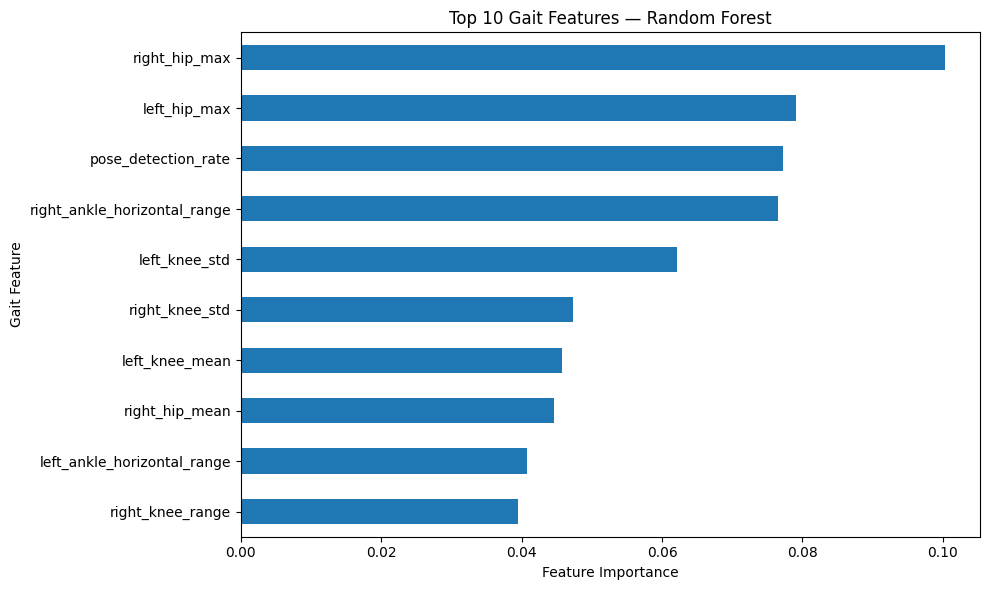


✅ STEP 9 FEATURE IMPORTANCE COMPLETE


In [ ]:
# ============================================
# STEP 9 — FEATURE IMPORTANCE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

feature_names = X_train.columns.tolist()

print("Number of features:", len(feature_names))


# =========================================================
# 1. LOGISTIC REGRESSION
# =========================================================

lr_pipeline = models["Logistic Regression"]

# Get the actual Logistic Regression classifier
lr_classifier = lr_pipeline[-1]

lr_importance = pd.Series(
    np.abs(lr_classifier.coef_[0]),
    index=feature_names
).sort_values(ascending=False)

print("\n" + "=" * 60)
print("TOP 10 LOGISTIC REGRESSION FEATURES")
print("=" * 60)

print(lr_importance.head(10))


# =========================================================
# 2. RANDOM FOREST
# =========================================================

rf_pipeline = models["Random Forest"]

# Get the actual Random Forest classifier
rf_classifier = rf_pipeline[-1]

rf_importance = pd.Series(
    rf_classifier.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("\n" + "=" * 60)
print("TOP 10 RANDOM FOREST FEATURES")
print("=" * 60)

print(rf_importance.head(10))


# =========================================================
# 3. PLOT RANDOM FOREST FEATURE IMPORTANCE
# =========================================================

top_features = rf_importance.head(10).sort_values()

plt.figure(figsize=(10, 6))

top_features.plot(kind="barh")

plt.title("Top 10 Gait Features — Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Gait Feature")

plt.tight_layout()
plt.show()


print("\n✅ STEP 9 FEATURE IMPORTANCE COMPLETE")

In [ ]:
# ============================================================
# STEP 10 — REPRODUCIBILITY CHECK
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# STEP 10 — FIXED REPRODUCIBILITY CHECK
# ============================================================

print("=" * 60)
print("STEP 10 — REPRODUCIBILITY CHECK")
print("=" * 60)

# Load test set
TEST_PATH = "/content/drive/MyDrive/KOA-PD-NM/test_set.csv"

test_df = pd.read_csv(TEST_PATH)

print("✅ Test set loaded:", test_df.shape)

# ------------------------------------------------------------
# IMPORTANT:
# Use EXACTLY the features used during model training
# ------------------------------------------------------------

feature_names = [
    "left_knee_mean",
    "left_knee_std",
    "left_knee_min",
    "left_knee_max",
    "left_knee_range",
    "right_knee_mean",
    "right_knee_std",
    "right_knee_min",
    "right_knee_max",
    "right_knee_range",
    "left_hip_mean",
    "left_hip_std",
    "left_hip_min",
    "left_hip_max",
    "left_hip_range",
    "right_hip_mean",
    "right_hip_std",
    "right_hip_min",
    "right_hip_max",
    "right_hip_range",
    "left_ankle_horizontal_range",
    "right_ankle_horizontal_range",
    "left_ankle_vertical_range",
    "right_ankle_vertical_range",
    "pose_detection_rate"
]

print("\nNumber of features:", len(feature_names))

# Check that all required features exist
missing_features = [
    f for f in feature_names
    if f not in test_df.columns
]

if missing_features:
    print("❌ Missing features:", missing_features)
    raise ValueError("Test set does not contain all required model features.")

# ------------------------------------------------------------
# Build X_test using ONLY the 25 training features
# ------------------------------------------------------------

X_test = test_df[feature_names].copy()

# Target
y_test = test_df["disease"]

print("X_test shape:", X_test.shape)
print("Expected: (32, 25)")

# ------------------------------------------------------------
# Load saved models
# ------------------------------------------------------------

MODEL_DIR = "/content/drive/MyDrive/KOA-PD-NM/models"

loaded_models = {}

model_files = {
    "Logistic Regression": "logistic_regression.joblib",
    "SVM": "svm.joblib",
    "Random Forest": "random_forest.joblib"
}

for name, filename in model_files.items():

    path = os.path.join(MODEL_DIR, filename)

    if os.path.exists(path):
        loaded_models[name] = joblib.load(path)
        print("✅ Loaded:", name)
    else:
        print("⚠️ Missing:", path)

# ------------------------------------------------------------
# Reproduce results
# ------------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

reproduced_results = []

print("\n" + "=" * 60)
print("REPRODUCED RESULTS")
print("=" * 60)

for name, model in loaded_models.items():
  predictions = model.predict(X_test)

# Convert numeric model predictions to the same labels
# used in test_set.csv
if set(predictions).issubset({0, 1}):
    predictions = np.where(
        predictions == 1,
        "KOA",
        "NM"
    )

accuracy = accuracy_score(y_test, predictions)

precision = precision_score(
    y_test,
    predictions,
    pos_label="KOA"
)

recall = recall_score(
    y_test,
    predictions,
    pos_label="KOA"
)

f1 = f1_score(
    y_test,
    predictions,
    pos_label="KOA"
)



    recall = recall_score(
        y_test,
        predictions,
        pos_label="KOA"
    )
    f1 = f1_score(
        y_test,
        predictions,
        pos_label="KOA"
    )

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    reproduced_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

# ------------------------------------------------------------
# Save reproducibility results
# ------------------------------------------------------------

results_df = pd.DataFrame(reproduced_results)

RESULT_PATH = "/content/drive/MyDrive/KOA-PD-NM/reproducibility_results.csv"

results_df.to_csv(
    RESULT_PATH,
    index=False
)

print("\n" + "=" * 60)
print("✅ REPRODUCIBILITY CHECK COMPLETE")
print("=" * 60)

print("\nResults:")
display(results_df)

print("\nSaved:", RESULT_PATH)

IndentationError: unexpected indent (514820932.py, line 159)

In [ ]:
import os

BASE = "/content/drive/MyDrive/KOA-PD-NM"

print("Files in project folder:")
for f in sorted(os.listdir(BASE)):
    print(f)

Files in project folder:
KOA-PD-NM
final_model_results.csv
gait_features.csv
gait_features_checkpoint.csv
models
test_indices.csv
test_predictions.csv
test_set.csv
video_metadata.csv


In [ ]:
# ============================================================
# STEP 10 — FINAL REPRODUCIBILITY CHECK
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("=" * 65)
print("STEP 10 — REPRODUCIBILITY CHECK")
print("=" * 65)

# ------------------------------------------------------------
# 1. LOAD TEST SET
# ------------------------------------------------------------

TEST_PATH = "/content/drive/MyDrive/KOA-PD-NM/test_set.csv"

test_df = pd.read_csv(TEST_PATH)

print("\n✅ Test set loaded:", test_df.shape)

# ------------------------------------------------------------
# 2. LOAD SAVED MODELS
# ------------------------------------------------------------

MODEL_DIR = "/content/drive/MyDrive/KOA-PD-NM/models"

model_files = {
    "Logistic Regression": "logistic_regression.joblib",
    "SVM": "svm.joblib",
    "Random Forest": "random_forest.joblib"
}

loaded_models = {}

for name, filename in model_files.items():

    path = os.path.join(MODEL_DIR, filename)

    if os.path.exists(path):
        loaded_models[name] = joblib.load(path)
        print("✅ Loaded:", name)
    else:
        print("❌ Missing:", path)

# ------------------------------------------------------------
# 3. GET THE EXACT FEATURES USED DURING TRAINING
# ------------------------------------------------------------

first_model = list(loaded_models.values())[0]

if hasattr(first_model, "feature_names_in_"):

    feature_names = list(first_model.feature_names_in_)

elif hasattr(first_model, "named_steps"):

    # For sklearn Pipeline
    feature_names = list(first_model.feature_names_in_)

else:

    raise ValueError(
        "Could not determine the original training feature names."
    )

print("\n" + "=" * 65)
print("ORIGINAL TRAINING FEATURES")
print("=" * 65)

print("Number of features:", len(feature_names))

for i, feature in enumerate(feature_names, 1):
    print(f"{i:2}. {feature}")

# ------------------------------------------------------------
# 4. CHECK REQUIRED FEATURES EXIST IN TEST SET
# ------------------------------------------------------------

missing_features = [
    feature
    for feature in feature_names
    if feature not in test_df.columns
]

if missing_features:

    print("\n❌ Missing features:")
    for feature in missing_features:
        print(" -", feature)

    raise ValueError("Test set is missing training features.")

# ------------------------------------------------------------
# 5. CREATE X_test USING ONLY ORIGINAL TRAINING FEATURES
# ------------------------------------------------------------

X_test = test_df[feature_names].copy()

y_test = test_df["disease"].copy()

print("\n" + "=" * 65)
print("FINAL TEST MATRIX")
print("=" * 65)

print("X_test shape:", X_test.shape)
print("Expected:", len(test_df), "videos ×", len(feature_names), "features")

# ------------------------------------------------------------
# 6. REPRODUCE MODEL RESULTS
# ------------------------------------------------------------

reproduced_results = []

print("\n" + "=" * 65)
print("REPRODUCED RESULTS")
print("=" * 65)

for name, model in loaded_models.items():

    predictions = model.predict(X_test)

    # Convert numeric predictions to original class labels
    if np.issubdtype(np.asarray(predictions).dtype, np.number):

        # Original training encoding:
        # 0 = NM
        # 1 = KOA
        predictions = np.where(
            predictions == 1,
            "KOA",
            "NM"
        )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        pos_label="KOA"
    )

    recall = recall_score(
        y_test,
        predictions,
        pos_label="KOA"
    )

    f1 = f1_score(
        y_test,
        predictions,
        pos_label="KOA"
    )

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    reproduced_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

# ------------------------------------------------------------
# 7. SAVE RESULTS
# ------------------------------------------------------------

results_df = pd.DataFrame(reproduced_results)

RESULT_PATH = (
    "/content/drive/MyDrive/KOA-PD-NM/"
    "reproducibility_results.csv"
)

results_df.to_csv(
    RESULT_PATH,
    index=False
)

# ------------------------------------------------------------
# 8. FINAL STATUS
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("FINAL REPRODUCIBILITY RESULTS")
print("=" * 65)

display(results_df)

print("\n✅ Saved:")
print(RESULT_PATH)

print("\n🎉 STEP 10 COMPLETE")

STEP 10 — REPRODUCIBILITY CHECK

✅ Test set loaded: (32, 34)
✅ Loaded: Logistic Regression
✅ Loaded: SVM
✅ Loaded: Random Forest

ORIGINAL TRAINING FEATURES
Number of features: 25
 1. left_knee_mean
 2. left_knee_std
 3. left_knee_min
 4. left_knee_max
 5. left_knee_range
 6. right_knee_mean
 7. right_knee_std
 8. right_knee_min
 9. right_knee_max
10. right_knee_range
11. left_hip_mean
12. left_hip_std
13. left_hip_min
14. left_hip_max
15. left_hip_range
16. right_hip_mean
17. right_hip_std
18. right_hip_min
19. right_hip_max
20. right_hip_range
21. left_ankle_horizontal_range
22. right_ankle_horizontal_range
23. left_ankle_vertical_range
24. right_ankle_vertical_range
25. pose_detection_rate

FINAL TEST MATRIX
X_test shape: (32, 25)
Expected: 32 videos × 25 features

REPRODUCED RESULTS

Logistic Regression
----------------------------------------
Accuracy : 0.8125
Precision: 0.8500
Recall   : 0.8500
F1-score : 0.8500

SVM
----------------------------------------
Accuracy : 0.7188
Prec

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.81250,0.85,0.85,0.850000
1,SVM,0.71875,0.72,0.90,0.800000
2,Random Forest,0.78125,0.76,0.95,0.844444



✅ Saved:
/content/drive/MyDrive/KOA-PD-NM/reproducibility_results.csv

🎉 STEP 10 COMPLETE


In [ ]:
print("TEST SET CHECK")
print("================")

print("Videos:", len(test_df))
print("Unique subjects:", test_df["subject_id"].nunique())

print("\nSubjects:")
print(sorted(test_df["subject_id"].astype(str).unique()))

print("\nVideos per subject:")
print(test_df.groupby("subject_id").size())

print("\nClass distribution:")
print(test_df["disease"].value_counts())

TEST SET CHECK
Videos: 32
Unique subjects: 12

Subjects:
['10', '11', '12', '13', '14', '16', '18', '24', '29', '3', '5', '9']

Videos per subject:
subject_id
3     2
5     4
9     2
10    2
11    4
12    2
13    2
14    4
16    2
18    4
24    2
29    2
dtype: int64

Class distribution:
disease
KOA    20
NM     12
Name: count, dtype: int64


In [ ]:
print("TEST SET FILES")
print("================")

for sid in sorted(test_df["subject_id"].astype(str).unique(), key=lambda x: int(x)):
    print(f"\nSubject {sid}:")
    print(test_df[test_df["subject_id"].astype(str) == sid]["filename"].tolist())

TEST SET FILES

Subject 3:
['003_KOA_01_MD.MOV', '003_KOA_02_MD.MOV']

Subject 5:
['005_KOA_01_MD.MOV', '005_KOA_02_MD.MOV', '005_KOA_01_SV.MOV', '005_KOA_02_SV.MOV']

Subject 9:
['009_NM_01.MOV', '009_NM_02.MOV']

Subject 10:
['010_NM_01.MOV', '010_NM_02.MOV']

Subject 11:
['011_KOA_01_MD.MOV', '011_KOA_02_MD.MOV', '011_KOA_01_SV.MOV', '011_KOA_02_SV.MOV']

Subject 12:
['012_KOA_01_MD.MOV', '012_KOA_02_MD.MOV']

Subject 13:
['013_NM_01.MOV', '013_NM_02.MOV']

Subject 14:
['014_KOA_01_EL.MOV', '014_KOA_02_EL.MOV', '014_KOA_01_SV.MOV', '014_KOA_02_SV.MOV']

Subject 16:
['016_KOA_01_MD.MOV', '016_KOA_02_MD.MOV']

Subject 18:
['018_KOA_01_MD.MOV', '018_KOA_02_MD.MOV', '018_NM_01.MOV', '018_NM_02.MOV']

Subject 24:
['024_NM_01.MOV', '024_NM_02.MOV']

Subject 29:
['029_NM_01.MOV', '029_NM_02.MOV']


In [ ]:
print("\nDUPLICATE FILENAMES")
print("===================")

dupes = test_df[test_df["filename"].duplicated(keep=False)]

if len(dupes) == 0:
    print("No duplicate filenames ✅")
else:
    print(dupes[["subject_id", "filename"]])


DUPLICATE FILENAMES
No duplicate filenames ✅


In [ ]:
for sid in sorted(test_df["subject_id"].astype(str).unique(), key=lambda x: int(x)):
    print(f"\nSubject {sid}:")
    print(test_df[test_df["subject_id"].astype(str) == sid]["filename"].tolist())


Subject 3:
['003_KOA_01_MD.MOV', '003_KOA_02_MD.MOV']

Subject 5:
['005_KOA_01_MD.MOV', '005_KOA_02_MD.MOV', '005_KOA_01_SV.MOV', '005_KOA_02_SV.MOV']

Subject 9:
['009_NM_01.MOV', '009_NM_02.MOV']

Subject 10:
['010_NM_01.MOV', '010_NM_02.MOV']

Subject 11:
['011_KOA_01_MD.MOV', '011_KOA_02_MD.MOV', '011_KOA_01_SV.MOV', '011_KOA_02_SV.MOV']

Subject 12:
['012_KOA_01_MD.MOV', '012_KOA_02_MD.MOV']

Subject 13:
['013_NM_01.MOV', '013_NM_02.MOV']

Subject 14:
['014_KOA_01_EL.MOV', '014_KOA_02_EL.MOV', '014_KOA_01_SV.MOV', '014_KOA_02_SV.MOV']

Subject 16:
['016_KOA_01_MD.MOV', '016_KOA_02_MD.MOV']

Subject 18:
['018_KOA_01_MD.MOV', '018_KOA_02_MD.MOV', '018_NM_01.MOV', '018_NM_02.MOV']

Subject 24:
['024_NM_01.MOV', '024_NM_02.MOV']

Subject 29:
['029_NM_01.MOV', '029_NM_02.MOV']


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!find /content/drive/MyDrive -name "*.ipynb"